# Experiment Results Plotting

This notebook is used to generate plots for the evaluation of different strategies based on the experiment results stored in JSON files.

## 1. Imports

In [2]:
import json
import os
from collections import defaultdict
from math import isnan
import numpy as np
from matplotlib import pyplot as plt


## 2. Configuration
Adjust the variables in this section to control which experiments and strategies are plotted.

In [ ]:
aggregate_funtion = np.average
# List of experiment names to load. These should correspond to the JSON file names in `data/evaluation`.
experiments = ["paper_evaluation_f1_score"]
# Set to a list of strategy names to plot only those, or None to plot all.
strategies_to_consider = [
    "Llama3_not_finetuned",
    "Llama3_finetuned_dc",
    "justine_v0",
    "justine_optimization_2",
    "Llama3_3_not_finetuned",
    "justine_3_3_one_prompt",
]
# If True, only data points where all strategies have results will be included.
require_same_results = False
# Labels for the plot axes
y_label = "Sparsity" if "sparsity" in experiments[0] else "Database F1 Score"
x_label = (
    "Altered names (%)"
    if "synonyms_used" in experiments[0]
    else (
        "Removed tables (%),\nRemoved columns (%)"
        if "table_and_columns_deleted" in experiments[0]
        else (
            "Removed columns (%)"
            if "columns_deleted" in experiments[0]
            else "Removed tables (%)"
        )
    )
)
# Identifier for data type specific evaluations
data_type_evaluation_identifier = "_only_"


### Plotting Labels and Colors

In [14]:
strategy_labels = {
    "gold_standard": "Gold Standard",
    "Llama3_not_finetuned": "Not fine-tuned\nLlama 3",
    "Llama3_finetuned_all_scenarios": "Fine-tuned Llama 3 (new)",
    "Llama3_finetuned_dc": "Fine-tuned\nLlama 3",
    "Heuristic_exact": "Heuristic (exact)",
    "Heuristic_fuzzy": "Heuristic (fuzzy)",
    "Heuristic_synonyms": "Heuristic (synonyms)",
    "GPT3_5": "GPT-3.5",
    "GPT4o_mini": "GPT-4o mini",
    "GPT4o": "GPT-4o",
    "justine_v0": "JUSTINE with\nfine-tuned Llama 3",
    "justine_optimization_1": "Remap Rows\nOptimization",
    "justine_optimization_2": "JUSTINE with\nfine-tuned Llama 3\nand optimization step",
    "justine_optimization_3": "Remap Rows\n-> Table Matching\nOptimization",
    "justine_optimization_4": "Table Matching\n-> Remap Rows\nOptimization",
    "Llama3_3_not_finetuned": "Not fine-tuned\nLlama 3.3",
    "justine_3_3_one_prompt": "JUSTINE with\nLlama 3.3\n(one prompt)",
}
strategy_colors = {
    "gold_standard": "#BBBBBB",
    "Llama3_finetuned": "#FFFFFF",
    "Llama3_finetuned_all_scenarios": "FFFFFF",
    "Llama3_finetuned_dc": "#4477AA",
    "Llama3_not_finetuned": "#66CCEE",
    "Llama3_3_not_finetuned": "#66CCEE",
    "Heuristic_exact": "#CCBB44",
    "Heuristic_fuzzy": "#EE6677",
    "Heuristic_synonyms": "#AA3377",
    "GPT3_5": "#CCBB44",
    "GPT4o_mini": "#EE6677",
    "GPT4o": "#AA3377",
    "justine_v0": "#AA3377",
    "justine_optimization_1": "#AA3377",
}
ratio_labels = {
    "0.1": r"$r_s \leq 10\%$",
    "0.3": r"$10\% < r_s \leq 30\%$",
    "0.7": r"$30\% < r_s < 70\%$",
    "0.9": r"$70\% \leq r_s < 90\%$",
    "1.0": r"$90\% \leq r_s$",
}
ratio_colors = {
    "0.1": "#4477AA",
    "0.3": "#66CCEE",
    "0.7": "#CCBB44",
    "0.9": "#EE6677",
    "1.0": "#AA3377",
}


## 3. Data Loading

In [9]:
def load_results(
    file_path: str,
    strategies_to_consider: list[str] = None,
    require_same_results: bool = True,
) -> tuple[list[float], dict[str, dict[str, list[float]]]]:
    with open(file_path, encoding="utf-8") as results_file:
        results = json.load(results_file)
    result_collector = (
        defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: [])))
        if data_type_evaluation_identifier in experiments[0]
        else defaultdict(lambda: defaultdict(lambda: []))
    )
    gold_standard_collector = []
    for database, results_per_db in sorted(results.items(), key=lambda x: x[0]):
        strategies = (
            strategies_to_consider if strategies_to_consider else list(results_per_db.keys())
        )
        if "gold_standard" not in strategies:
            strategies.append("gold_standard")
        if require_same_results and any(
            [
                len(results_per_db[s]) == 0
                for s in strategies
                if isinstance(results_per_db[s], dict)
            ]
        ):
            continue
        for strategy in strategies:
            if strategy not in results_per_db:
                continue
            if strategy == "gold_standard":
                # Is only required in sparsity where no data type evaluation is done
                if data_type_evaluation_identifier in experiments[0]:
                    continue
                if isnan(results_per_db[strategy]):
                    continue
                gold_standard_collector.append(results_per_db[strategy])
            else:
                for parameters, result_per_parameters in results_per_db[
                    strategy
                ].items():
                    if require_same_results and any(
                        [
                            parameters not in results_per_db[s]
                            for s in strategies
                            if s != "gold_standard" and s in results_per_db
                        ]
                    ):
                        continue
                    if data_type_evaluation_identifier in experiments[0]:
                        for (
                            data_type_ratio,
                            results_per_ratio,
                        ) in result_per_parameters.items():
                            if isnan(results_per_ratio):
                                continue
                            result_collector[strategy][parameters][
                                data_type_ratio
                            ].append(results_per_ratio)
                    else:
                        if isnan(result_per_parameters):
                            continue
                        result_collector[strategy][parameters].append(
                            result_per_parameters
                        )
    return gold_standard_collector, result_collector


## 4. Plotting Functions

In [10]:
def boxplot_one_parameter_all_strategies(
    gs_results: list[float], results: dict[str, dict[str, list[float]]], parameter: str
):
    values = []
    labels = []
    titles = []
    if "sparsity" in experiments[0] or "number_of_tables" in experiments[0]:
        print(
            "Gold Standard",
            "Average: ",
            np.average(gs_results),
            ", Std: ",
            np.std(gs_results),
            ", Values:",
            gs_results,
        )
        values.append(gs_results)
        labels.append([""])
        titles.append(strategy_labels["gold_standard"])
    for strategy, label in strategy_labels.items():
        if strategy not in results:
            continue
        parameters_values = (
            dict(sorted(results[strategy].items(), key=lambda x: float(x[0])))
            if (
                "table_and_columns_deleted" not in experiments[0]
                and "existing_database_schema" not in experiments[0]
                and "paper_evaluation" not in experiments[0]
            )
            else dict(
                sorted(
                    results[strategy].items(),
                    key=lambda x: tuple([float(p) for p in x[0].split("_")]),
                )
            )
        )
        print(
            strategy,
            "Average: ",
            np.average(parameters_values[parameter]),
            ", Std: ",
            np.std(parameters_values[parameter]),
            ", Values:",
            parameters_values[parameter],
        )
        values.append(parameters_values[parameter])
        labels.append(label)
    fig, axs = plt.subplots(figsize=(8, 4))
    axs.set_ylabel(y_label)
    axs.set_ylim(-0.02, 1.02)
    axs.grid(True, axis="y", color="0.9", linestyle="--")
    axs.boxplot(
        values,
        tick_labels=labels,
        showmeans=True,
    )
    fig.tight_layout()
    plt.savefig(
        os.path.join(
            "plots",
            f"{experiments[0]}{'_selected_strategies' if strategies_to_consider else '_all_strategies'}_{parameter}.pdf",
        ),
        format="pdf",
    )
    plt.show()


In [ ]:
def boxplot_one_parameter_all_strategies_multiple_scores(
    gs_results: list[float],
    results: list[dict[str, dict[str, list[float]]]],
    parameter: str,
):
    values = [[] for _ in range(len(results))]
    labels = []
    titles = []
    if "sparsity" in experiments[0]:
        values.append([gs_results])
        labels.append([""])
        titles.append(strategy_labels["gold_standard"])
    for strategy, label in strategy_labels.items():
        if strategy not in results[0]:
            continue
        for i, result in enumerate(results):
            parameters_values = (
                dict(sorted(result[strategy].items(), key=lambda x: float(x[0])))
                if (
                    "table_and_columns_deleted" not in experiments[0]
                    and "existing_database_schema" not in experiments[0]
                    and "paper_evaluation" not in experiments[0]
                )
                else dict(
                    sorted(
                        result[strategy].items(),
                        key=lambda x: tuple([float(p) for p in x[0].split("_")]),
                    )
                )
            )
            print(
                strategy,
                "Average: ",
                np.average(parameters_values[parameter]),
                ", Std: ",
                np.std(parameters_values[parameter]),
            )
            values[i].append(parameters_values[parameter])
        labels.append(label)
    x_base = np.arange(len(labels))
    offset = 0.2
    box_width = 0.3
    font = {"size": 14}
    plt.rc("font", **font)
    fig, axs = plt.subplots(figsize=(8, 4))
    axs.set_ylabel(y_label)
    axs.set_ylim(-0.02, 1.02)
    axs.grid(True, axis="y", color="0.9", linestyle="--")
    axs.set_xticks(x_base)
    axs.set_xticklabels(labels)
    bp_A = axs.boxplot(
        values[0],
        positions=x_base - offset,
        widths=box_width,
        showmeans=True,
        manage_ticks=False,
        boxprops=dict(color="#6ABFA3"),
        whiskerprops=dict(color="#6ABFA3"),
        capprops=dict(color="#6ABFA3"),
    )
    bp_B = axs.boxplot(
        values[1],
        positions=x_base + offset,
        widths=box_width,
        showmeans=True,
        manage_ticks=False,
        boxprops=dict(color="#1D3A8F"),
        whiskerprops=dict(color="#1D3A8F"),
        capprops=dict(color="#1D3A8F"),
    )
    axs.plot(
        [],
        [],
        color="#6ABFA3",
        marker="s",
        markersize=8,
        linestyle="None",
        label="F1 Score",
    )
    axs.plot(
        [],
        [],
        color="#1D3A8F",
        marker="s",
        markersize=8,
        linestyle="None",
        label="Strict F1 Score",
    )
    axs.legend()
    fig.tight_layout()
    plt.savefig(
        os.path.join(
            "plots",
            f"both_f1_scores{'_selected_strategies' if strategies_to_consider else '_all_strategies'}_{parameter}.pdf",
        ),
        format="pdf",
    )
    plt.show()


In [ ]:
def boxplot_parameters_all_strategies(
    gs_results: list[float], results: dict[str, dict[str, list[float]]]
):
    values = []
    labels = []
    titles = []
    if "sparsity" in experiments[0]:
        values.append([gs_results])
        labels.append([""])
        titles.append(strategy_labels["gold_standard"])
    for strategy, label in strategy_labels.items():
        if strategy not in results:
            continue
        parameters_values = (
            dict(sorted(results[strategy].items(), key=lambda x: float(x[0])))
            if (
                "table_and_columns_deleted" not in experiments[0]
                and "existing_database_schema" not in experiments[0]
                and "paper_evaluation" not in experiments[0]
            )
            else dict(
                sorted(
                    results[strategy].items(),
                    key=lambda x: tuple([float(p) for p in x[0].split("_")]),
                )
            )
        )
        for p, v in parameters_values.items():
            print(strategy, p, np.average(v))
        values.append(list(parameters_values.values()))
        labels.append(
            [
                (
                    int(100 * float(parameter))
                    if (
                        "table_and_columns_deleted" not in experiments[0]
                        and "existing_database_schema" not in experiments[0]
                        and "paper_evaluation" not in experiments[0]
                    )
                    else ",\n".join(
                        [str(int(100 * float(p))) for p in parameter.split("_")]
                    )
                )
                for parameter in parameters_values.keys()
            ]
        )
        titles.append(label)
    fig, axs = plt.subplots(
        1, len(values), sharey=True, figsize=(2 * len(values) + 2, 4)
    )
    axs[0].set_ylabel(y_label)
    for index in range(len(values)):
        axs[index].set_title(titles[index])
        if titles[index] != strategy_labels["gold_standard"]:
            axs[index].set_xlabel(x_label)
        axs[index].set_ylim(-0.02, 1.02)
        axs[index].grid(True, axis="y", color="0.9", linestyle="--")
        axs[index].boxplot(
            values[index],
            tick_labels=labels[index],
            showmeans=True,
        )
    fig.tight_layout()
    plt.savefig(
        os.path.join(
            "plots",
            f"{experiments[0]}{'_selected_strategies' if strategies_to_consider else '_all_strategies'}.png",
        ),
    )
    plt.show()


In [ ]:
def barplot_all_strategies(gs_results: list[float], results: dict[str, dict[str, list[float]]], parameter: str):
    parameter_results = {
        strategy: results[parameter] for strategy, results in results.items()
    }
    number_of_strategies = len(parameter_results)
    fig, axs = plt.subplots(figsize=(12, 4))
    plotted_strategies = 0
    if "sparsity" in experiments[0]:
        number_of_strategies += 1
        axs.bar(
            [
                (number_of_strategies + 5) * result_index + plotted_strategies * 1.5
                for result_index in range(len(gs_results))
            ],
            height=gs_results,
            width=[1] * len(gs_results),
            color=strategy_colors["gold_standard"],
            label=strategy_labels["gold_standard"],
        )
        plotted_strategies += 1
    for strategy_label in strategy_labels.items():
        if strategy_label[0] not in parameter_results:
            continue
        results = parameter_results[strategy_label[0]]
        axs.bar(
            [
                (number_of_strategies + 5) * result_index + plotted_strategies * 1.5
                for result_index in range(len(results))
            ],
            height=results,
            width=[1] * len(results),
            color=strategy_colors[strategy_label[0]],
            label=strategy_label[1],
        )
        plotted_strategies += 1
    axs.set_axisbelow(True)
    axs.grid(True, axis="y", color="0.9", linestyle="--")
    axs.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
    axs.set_xlim(
        -1,
        (number_of_strategies + 5) * (len(list(parameter_results.values())[0]) - 1)
        + (plotted_strategies - 1) * 1.5
        + 1,
    )
    axs.set_ylim(0, 1)
    axs.set_ylabel(y_label)
    lgd = fig.legend(loc="outside lower center", ncols=plotted_strategies)
    plt.savefig(
        os.path.join(
            "plots",
            f"{experiments[0]}_{parameter}_bar{'_selected_strategies' if strategies_to_consider else ''}.png",
        ),
        bbox_extra_artists=(lgd,),
        bbox_inches="tight",
    )
    plt.show()


In [ ]:
def barplot_ratio_averages(
    results: dict[str, dict[str, dict[str, list[float]]]],
    strategy: str,
    parameters: str,
):
    results = {
        ratio: np.average(results[strategy][parameters][ratio])
        for ratio in ratio_labels.keys()
    }
    fig, axs = plt.subplots(figsize=(6, 4))
    plt.bar(
        [index * 1.5 for index in range(len(results))],
        height=results.values(),
        width=[1] * len(results),
        color=[ratio_colors[ratio] for ratio in results.keys()],
    )
    axs.set_axisbelow(True)
    axs.grid(True, axis="y", color="0.9", linestyle="--")
    axs.tick_params(axis="x", which="both", bottom=False, top=False)
    axs.set_xlim(
        -1,
        (len(results) - 1) * 1.5 + 1,
    )
    axs.set_xticks(
        [index * 1.5 for index in range(len(results))],
        [ratio_labels[ratio] for ratio in results.keys()],
        rotation=25,
    )
    axs.set_ylim(0, 1)
    axs.set_ylabel(y_label)
    plt.savefig(
        os.path.join(
            "plots",
            f"{experiments[0]}_{strategy}_{parameters}_bar.png",
        ),
        bbox_inches="tight",
    )
    plt.show()


In [ ]:
def scatter_all_strategies(
    results_x: dict[str, dict[str, list[float]]],
    results_y: dict[str, dict[str, list[float]]],
):
    fig, axs = plt.subplots(figsize=(6, 6))
    max_parameters = 0
    for strategy, label in strategy_labels.items():
        if strategy not in results_y:
            continue
        max_parameters = max(max_parameters, len(results_y[strategy]))
        parameters_values = (
            sorted(results_y[strategy].keys(), key=lambda x: float(x))
            if "table_and_columns_deleted" not in experiments[0]
            else sorted(
                results_y[strategy].keys(),
                key=lambda x: tuple([float(p) for p in x.split("_")]),
            )
        )
        for parameter in parameters_values:
            if parameter != "1.0_1.0":
                continue
            axs.scatter(
                *zip(
                    *list(
                        zip(
                            results_x,
                            results_y[strategy][parameter],
                        )
                    )
                ),
                c=strategy_colors[strategy],
                label=label,
                s=20,
            )
    axs.set_xscale("log")
    axs.set_xlabel("Number of columns in gold standard database")
    axs.set_ylim(0, 1)
    axs.set_ylabel(y_label)
    axs.legend()
    plt.savefig(
        os.path.join(
            "plots",
            f"{experiments[0]}_scatter{'_selected_strategies' if strategies_to_consider else ''}.png",
        ),
        bbox_inches="tight",
    )
    plt.show()


## 5. Execution
This section loads the data and calls the desired plotting function. You can choose which function to call.

Llama3_not_finetuned Average:  0.489734517426928 , Std:  0.11923042173112723 , Values: [0.4540642573931996, 0.29316825223266546, 0.35431437389770726, 0.47377029385785424, 0.298107558661597, 0.458574566276027, 0.543638161295102, 0.47445613483356497, 0.4547337120653684, 0.473199149496915, 0.501399305366393, 0.6337021967893847, 0.29225439954880106, 0.5107168833889483, 0.26998686317833837, 0.5700104435212252, 0.5170556875745, 0.5607386969291731, 0.5382922692852093, 0.5184620268974336, 0.3380528366821623, 0.6741217116217115, 0.578690792512517, 0.6173701493937723, 0.48369963369963376, 0.5923534798534797, 0.7396491422807211, 0.519550883613724, 0.6229414891953592, 0.6395632145632146, 0.4694560564112838, 0.24685556952738663, 0.4835706306603902, 0.5925529445156195, 0.26238983003496347, 0.4505789295719038, 0.41893227458575005, 0.4989782748574926, 0.5522337097391783, 0.6171939112674482]
Llama3_finetuned_dc Average:  0.4908370383487372 , Std:  0.1275320172975719 , Values: [0.2984200109727185, 0.323

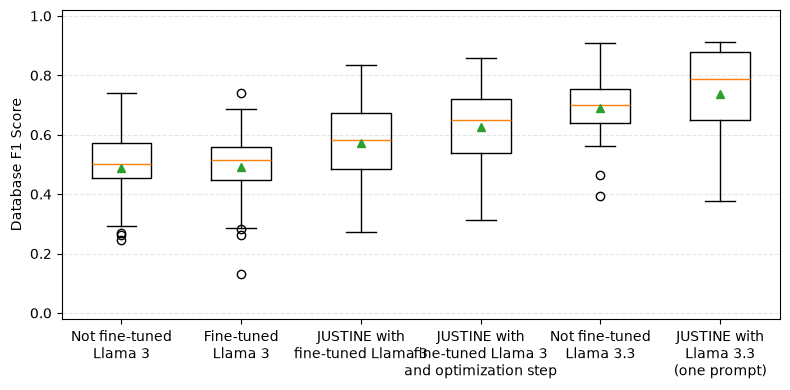

In [17]:
if len(experiments) > 1:
    loaded_results = []
    for experiment in experiments:
        gs_results, result = load_results(
            os.path.join("results", f"{experiment}.json"),
            strategies_to_consider,
            require_same_results,
        )
        loaded_results.append(result)
else:
    gs_results, results = load_results(
        os.path.join("results", f"{experiments[0]}.json"),
        strategies_to_consider,
        require_same_results,
    )
# Call the desired plotting function here
# Example for a single experiment:
if len(experiments) == 1:
    # Call the function for the paper evaluation
    boxplot_one_parameter_all_strategies(gs_results, results, "0.2_0.375_0.5_0.5")
    # boxplot_parameters_all_strategies(gs_results, results)
    # barplot_all_strategies(gs_results, results, "0.2_0.375_0.5_0.5")
    # barplot_ratio_averages(results, "Llama3_finetuned_dc", "0.0")
# Example for multiple experiments (e.g., for comparing f1 scores):
if len(experiments) > 1:
    # Call the function for the paper evaluation
    boxplot_one_parameter_all_strategies_multiple_scores(gs_results, loaded_results, "0.2_0.375_0.5_0.5")